In [1]:
# ------------------------------------------------------------
# 0) Install libraries
# ------------------------------------------------------------
!pip install lifelines

# ------------------------------------------------------------
# 1) Imports
# ------------------------------------------------------------
import os, random, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import CoxPHFitter, KaplanMeierFitter
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 2) Reproducibility
# ------------------------------------------------------------
RNG_SEED = 42
def seed_all(seed=RNG_SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

seed_all(RNG_SEED)

# ------------------------------------------------------------
# 3) Load data
# ------------------------------------------------------------
url = "https://ndownloader.figshare.com/files/62102364"
df = pd.read_csv(url)
df_raw = df.drop(columns=["Unnamed: 0"], errors="ignore")

# Basic sanity checks (optional)
required_cols = ["cvd_time", "cvd_event", "IRSD_quintile", "Age", "smoking_status",
                 "AF", "CKD", "diabetes", "HbA1c", "eGFR", "SBP"]
missing = [c for c in required_cols if c not in df_raw.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.4 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=6c9045c18a8ba6762ab897ace3462d5971672d9853a9722c2971ec383c1d5639
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [3]:
df_raw.head()

,IRSD_quintile,Age,smoking_status,BMI,diabetes,CKD,HbA1c,eGFR,SBP,AF,cvd_event,cvd_time
0,4,50.395265,non,28.166346,0,0,4.317890,83.077560,118.668194,0,1,2.963423
1,3,39.226761,ex,16.825992,0,0,4.700951,81.488401,123.719732,0,0,4.407252
2,5,55.489004,non,23.523419,0,0,3.669685,86.779230,126.650517,0,0,4.490739
3,4,51.910529,non,31.981932,0,0,4.486977,94.704093,113.889670,0,0,4.888965
4,1,47.091570,ex,25.351159,0,0,4.315440,86.336256,125.912615,0,0,4.490326


In [4]:
# -----------------------------
# 2) Exclude outcome features
# -----------------------------
outcome_cols = ["cvd_event", "cvd_time"]
X_df = df_raw.drop(columns=outcome_cols)

# -----------------------------
# 3) Preprocess: one-hot encode categoricals
# -----------------------------
X_df = pd.get_dummies(X_df, columns=["smoking_status"], drop_first=False)

bool_cols = X_df.select_dtypes(include=["bool"]).columns
X_df[bool_cols] = X_df[bool_cols].astype(int)

non_numeric = [c for c in X_df.columns if not np.issubdtype(X_df[c].dtype, np.number)]
if non_numeric:
    raise ValueError(f"Non-numeric columns remain after encoding: {non_numeric}")

# -----------------------------
# 4) Scale
# -----------------------------
scaler = StandardScaler()
X = scaler.fit_transform(X_df.values)

# -----------------------------
# 5) (Optional) PCA before t-SNE
# -----------------------------
pca = PCA(n_components=min(30, X.shape[1]), random_state=42)
X_pca = pca.fit_transform(X)

# -----------------------------
# 6) t-SNE
# -----------------------------
rng = np.random.default_rng(42)
sample_n = 10000
idx = rng.choice(X_pca.shape[0], size=sample_n, replace=False)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42,
    n_iter=1500,
    verbose=2,
)
Z = tsne.fit_transform(X_pca[idx])

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.053s...
[t-SNE] Computed neighbors for 10000 samples in 4.289s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 0.545275
[t-SNE] Computed conditional probabilities in 0.739s
[t-SNE] Iteration 50: error = 91.1133804, gradient norm = 0.0132433 (50 iterations in 18.193s)
[t-SNE] I

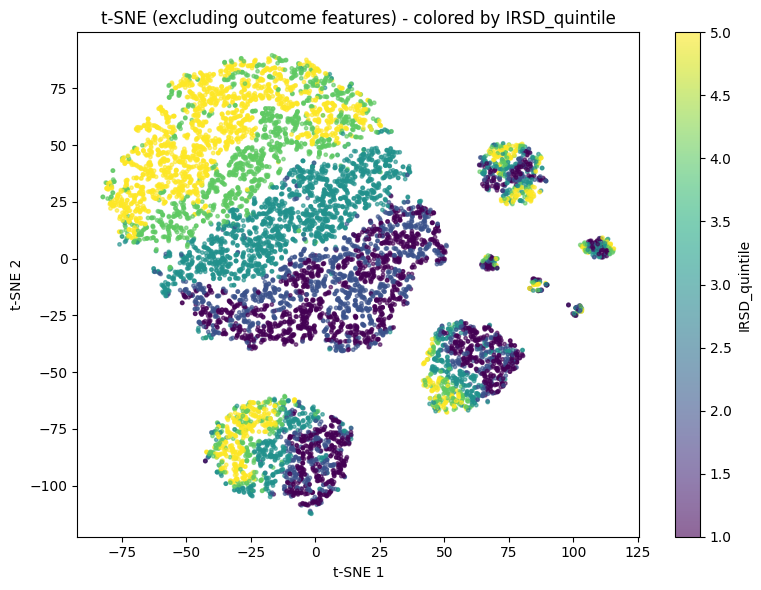

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(
    Z[:, 0], Z[:, 1],
    s=6, alpha=0.6,
    c=df_raw.iloc[idx]["IRSD_quintile"].to_numpy(),
    cmap="viridis"
)
plt.title("t-SNE (excluding outcome features) - colored by IRSD_quintile")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(label="IRSD_quintile")
plt.tight_layout()
plt.show()

In [6]:
df_raw.columns

Index(['IRSD_quintile', 'Age', 'smoking_status', 'BMI', 'diabetes', 'CKD',
       'HbA1c', 'eGFR', 'SBP', 'AF', 'cvd_event', 'cvd_time'],
      dtype='object')

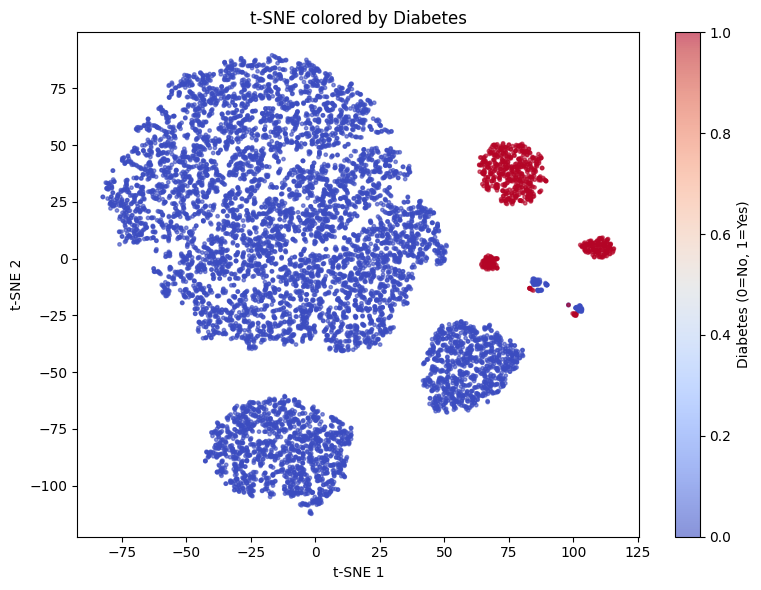

In [7]:
plt.figure(figsize=(8, 6))

plt.scatter(
    Z[:, 0], Z[:, 1],
    s=6,
    alpha=0.6,
    c=df_raw.iloc[idx]["diabetes"].to_numpy(),
    cmap="coolwarm"
)

plt.title("t-SNE colored by Diabetes")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(label="Diabetes (0=No, 1=Yes)")
plt.tight_layout()
plt.show()

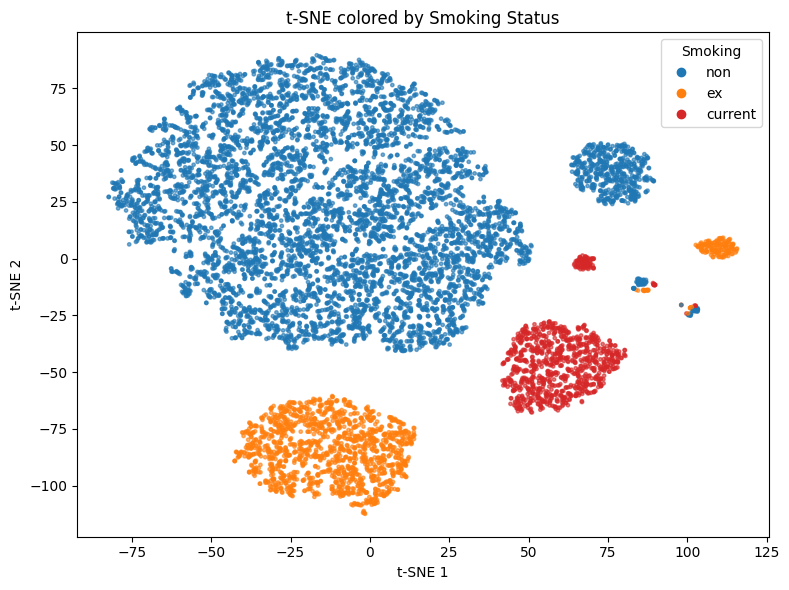

In [8]:
import matplotlib.pyplot as plt
import numpy as np

smoking_sample = df_raw.iloc[idx]["smoking_status"]

categories = ["non", "ex", "current"]

color_map = {
    "non": "#1f77b4",
    "ex": "#ff7f0e",
    "current": "#d62728"
}

colors = smoking_sample.map(color_map)

plt.figure(figsize=(8, 6))

plt.scatter(
    Z[:, 0],
    Z[:, 1],
    s=6,
    alpha=0.6,
    c=colors
)

plt.title("t-SNE colored by Smoking Status")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

handles = [
    plt.Line2D([], [], marker="o", linestyle="", color=color_map[c], label=c)
    for c in categories
]

plt.legend(handles=handles, title="Smoking")
plt.tight_layout()
plt.show()

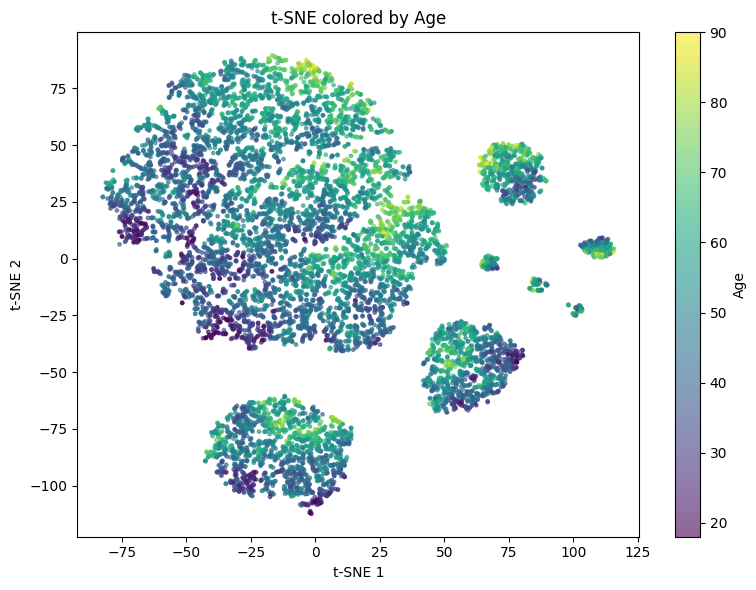

In [9]:
plt.figure(figsize=(8, 6))

plt.scatter(
    Z[:, 0], Z[:, 1],
    s=6,
    alpha=0.6,
    c=df_raw.iloc[idx]["Age"].to_numpy(),
    cmap="viridis"
)

plt.title("t-SNE colored by Age")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(label="Age")
plt.tight_layout()
plt.show()